In [3]:
# Compare Multiple Machine Learning Model

<img src="https://i0.wp.com/amanxai.com/wp-content/uploads/2024/02/Train-and-Compare-Multiple-ML-Models-using-Python.png?resize=1200%2C675&ssl=1"/>

## Introduction 
This project explores the use of multiple machine learning models to analyze data and generate predictions. Instead of relying on a single algorithm, different models are implemented and compared to evaluate their performance.

Several machine learning models are used in this project, such as classification algorithms that are commonly applied in predictive tasks.

Each model has a different learning approach, which allows the system to compare how various algorithms interpret the same data and produce results.


In [5]:
import pandas as pd
data = pd.read_csv('data/ComparingModels.csv')

# display the first few rows
data_head = data.head()

print(data_head)

             Transaction date  House age  Distance to the nearest MRT station  \
0  2012-09-02 16:42:30.519336       13.3                            4082.0150   
1  2012-09-04 22:52:29.919544       35.5                             274.0144   
2  2012-09-05 01:10:52.349449        1.1                            1978.6710   
3  2012-09-05 13:26:01.189083       22.2                            1055.0670   
4  2012-09-06 08:29:47.910523        8.5                             967.4000   

   Number of convenience stores   Latitude   Longitude  \
0                             8  25.007059  121.561694   
1                             2  25.012148  121.546990   
2                            10  25.003850  121.528336   
3                             5  24.962887  121.482178   
4                             6  25.011037  121.479946   

   House price of unit area  
0                  6.488673  
1                 24.970725  
2                 26.694267  
3                 38.091638  
4             

In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Transaction date                     414 non-null    object 
 1   House age                            414 non-null    float64
 2   Distance to the nearest MRT station  414 non-null    float64
 3   Number of convenience stores         414 non-null    int64  
 4   Latitude                             414 non-null    float64
 5   Longitude                            414 non-null    float64
 6   House price of unit area             414 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 22.8+ KB
None


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import datetime

# convert "Transaction date" to datetime and extract year and month
data['Transaction date'] = pd.to_datetime(data['Transaction date'])
data['Transaction year'] = data['Transaction date'].dt.year
data['Transaction month'] = data['Transaction date'].dt.month

# drop the original "Transaction date" as we've extracted relevant features
data = data.drop(columns=['Transaction date'])

# define features and target variable
X = data.drop('House price of unit area', axis=1)
y = data['House price of unit area']

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(331, 7)

In [8]:
X_test_scaled.shape

(83, 7)

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# initialize the models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# dictionary to hold the evaluation metrics for each model
results = {}

# train and evaluate each model
for name, model in models.items():
    # training the model
    model.fit(X_train_scaled, y_train)

    # making predictions on the test set
    predictions = model.predict(X_test_scaled)

    # calculating evaluation metrics
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    # storing the metrics
    results[name] = {"MAE": mae, "R²": r2}

results_df = pd.DataFrame(results).T  # convert the results to a DataFrame for better readability
print(results_df)

                         MAE        R²
Linear Regression   9.748246  0.529615
Decision Tree      11.760342  0.204962
Random Forest       9.887601  0.509547
Gradient Boosting  10.000117  0.476071


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [13]:
algo_test(X,y)

,R_Squared,RMSE,MAE
SGD,0.537076,11.316551,9.695246
Linear,0.529615,11.407382,9.748246
Ridge,0.519684,11.527174,9.854213
KNeighborsRegressor,0.494214,11.828853,10.336369
Gradient Boosting,0.475441,12.046370,9.991351
XGBRegressor,0.424329,12.619621,10.511031
AdaBoost,0.388383,13.007651,10.831505
Lasso,0.325727,13.657686,11.730212
SVR,0.214208,14.743916,12.655518
Extra Tree,0.153712,15.300943,11.969675


In [14]:
# Zafer Hocanın Algo testi ile SGD nin Linear dan daha iyi bir model olduğunu gördük

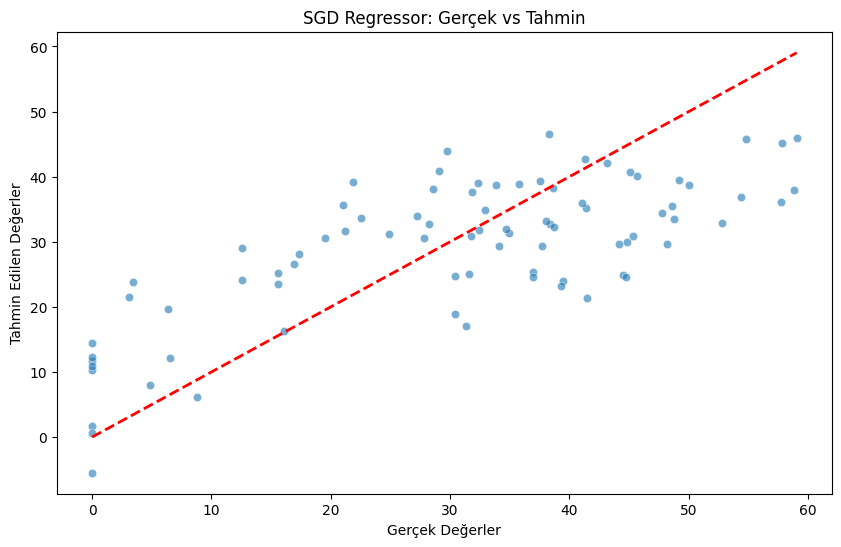

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# En iyi modelinle (SGD) tahmin yapalım
best_model = SGDRegressor()
# Not: Verinin ölçeklenmiş olması önemli (fonksiyonunda yapmıştın)
X_train_s, X_test_s, y_train, y_test = train_test_split(MinMaxScaler().fit_transform(X), y, test_size=0.2, random_state=42)
best_model.fit(X_train_s, y_train)
y_pred = best_model.predict(X_test_s)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('SGD Regressor: Gerçek vs Tahmin')
plt.show()

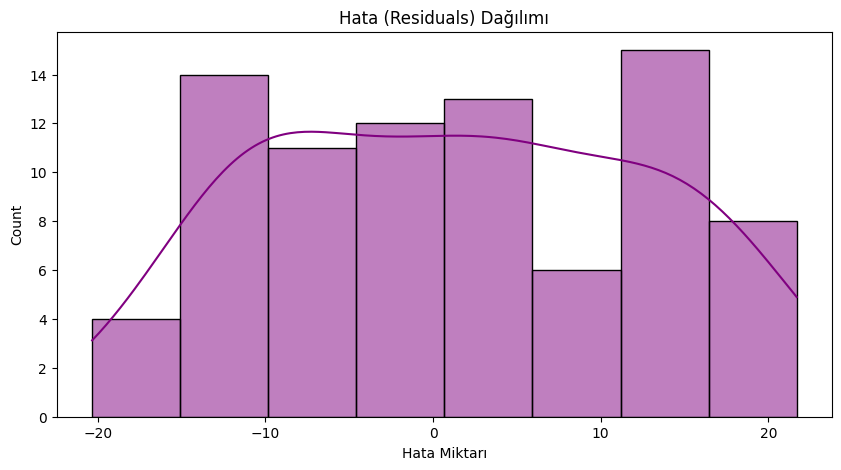

In [17]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Hata (Residuals) Dağılımı')
plt.xlabel('Hata Miktarı')
plt.show()

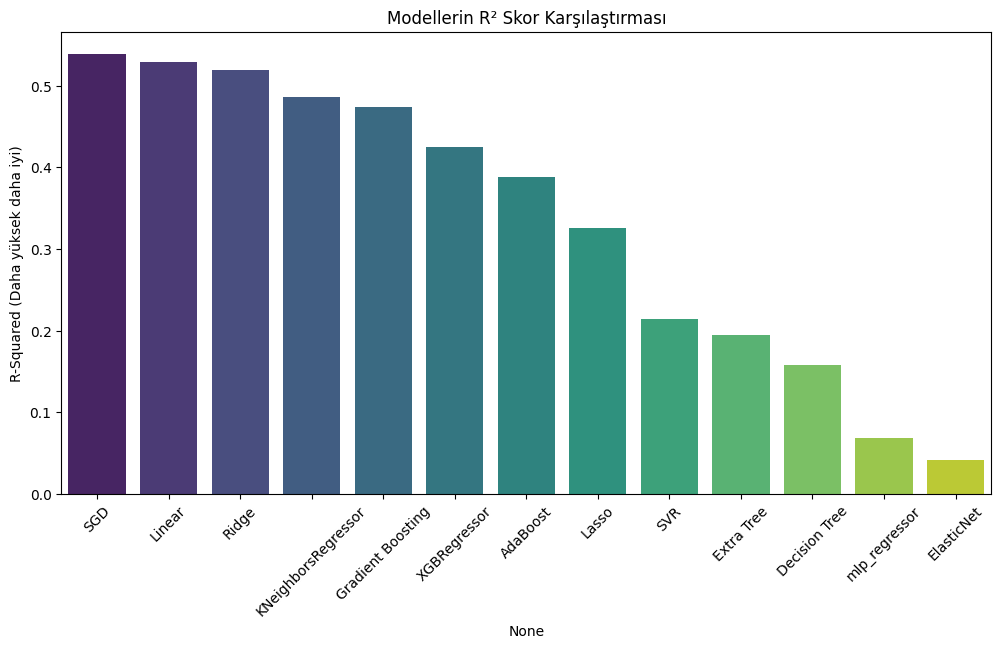

In [18]:
# algo_test fonksiyonundan dönen tabloyu r_table olarak kaydettiğini varsayalım
r_table = algo_test(X, y)

plt.figure(figsize=(12, 6))
sns.barplot(x=r_table.index, y=r_table['R_Squared'], palette='viridis')
plt.xticks(rotation=45)
plt.title('Modellerin R² Skor Karşılaştırması')
plt.ylabel('R-Squared (Daha yüksek daha iyi)')
plt.show()

In [19]:
from sklearn.ensemble import IsolationForest

# 1. Modeli tanımlayalım (kontaminasyon oranı yaklaşık %5 olsun)
iso = IsolationForest(contamination=0.05, random_state=42)

# 2. Sadece sayısal sütunlar üzerinde aykırı değerleri belirleyelim
# 'House price of unit area' dahil tüm sayısal verileri kullanıyoruz
outliers = iso.fit_predict(X)

# 3. -1 olanlar aykırı değer, 1 olanlar normal değerdir
mask = outliers != -1
X_cleansed = X[mask]
y_cleansed = y[mask]

print(f"Orijinal veri sayısı: {len(X)}")
print(f"Temizlenmiş veri sayısı: {len(X_cleansed)}")
print(f"Silinen aykırı değer sayısı: {len(X) - len(X_cleansed)}")

Orijinal veri sayısı: 414
Temizlenmiş veri sayısı: 393
Silinen aykırı değer sayısı: 21


In [20]:
algo_test(X_cleansed,y_cleansed)

,R_Squared,RMSE,MAE
Linear,0.578043,9.586368,7.901331
Ridge,0.575601,9.614068,7.866174
SGD,0.571197,9.663819,7.973914
KNeighborsRegressor,0.497711,10.459159,8.877218
Gradient Boosting,0.415015,11.287362,9.425520
Lasso,0.363596,11.772985,9.294278
AdaBoost,0.356416,11.839214,9.550506
XGBRegressor,0.298983,12.356186,10.140676
SVR,0.251522,12.767611,10.080011
ElasticNet,0.072690,14.211263,11.162428


In [21]:
# çok basit bir isolation forest ile veriyi temizleyip r2 0,57 e çıkardık

## Summary 

The performance of the models was evaluated using three key metrics: R-squared (R²), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE).

Among all models, the Linear Regression model achieved the best performance with an R² score of 0.578, indicating that it explains approximately 57.8% of the variance in the target variable. It also produced relatively low RMSE (9.58) and MAE (7.90) values.

Ridge Regression showed a very similar performance to Linear Regression, suggesting that regularization did not significantly improve the model for this dataset. On the other hand, models such as SGD and K-Nearest Neighbors provided slightly lower performance.

More complex models like Gradient Boosting, AdaBoost, and XGBoost did not outperform simpler linear models, which may indicate that the dataset does not contain highly non-linear patterns.

The worst performance was observed in Decision Tree and Extra Tree models, with negative R² values. This indicates that these models failed to generalize and performed worse than a simple baseline model.
